### Density analysis across window sizes

Let's analyze how the distribution of different antisense transcription types changes across different window sizes

# Analysis transcription type
## Analysis of antisense transcription
### Author: Martin Loza
### Date: 26/01/18


In [2]:
# Change R language to English
Sys.setenv(LANGUAGE = "en")

# Init
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(ggplot2)
    library(patchwork)
})

# Local variables 
seed = 777
date = "260117"

# Define colors for strand plots
red = "#E41A1C"
blue = "#377EB8"
# Define colors for gene types
green = "#4DAF4A"
purple = "#984EA3"
text_size = 18
width = 18.6
dot_size = 4
line_size = 1.5
dpi = 300

in_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/Annotated_ncRNA_PCG_pairs/"
ensembl_raw_annotation_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/Data/ENSEMBL/selected/"
out_dir = "/mnt/c/Users/Marti/Documents/Projects/lncRNA_TF_pairs_analysis/04_Figure_window_size_and_GO/Analysis_transcription_type/Plots/"

# Local Functions

# Simplified function to calculate density metrics for a given window size
calculate_density_metrics <- function(data, window_size, distance_column = "abs_strand_distance") {
    # Filter data within the window
    filtered_data <- data %>%
        filter(!!sym(distance_column) <= window_size)
    
    # Calculate counts and density
    metrics <- filtered_data %>%
        group_by(ncrna_strand) %>%
        summarise(count = n(), .groups = 'drop') %>%
        mutate(
            window_size = window_size,
            strand = ifelse(ncrna_strand == 1, "Forward", "Reverse"),
            density = count / window_size
        )
    
    return(metrics)
}

# Function to annotate antisense transcription relationship between lncRNA and PCG
annotate_transcription_relation <- function(data) {  
  data %>%  
    # 1. Compute TSS (head) and TES (tail) using strand information.  
    mutate(  
      lncRNA_tss = if_else(lncRNA_strand == 1, lncRNA_start, lncRNA_end),  
      lncRNA_tes = if_else(lncRNA_strand == 1, lncRNA_end,   lncRNA_start),  
      pcg_tss    = if_else(pcg_strand    == 1, pcg_start,    pcg_end),  
      pcg_tes    = if_else(pcg_strand    == 1, pcg_end,      pcg_start)  
    ) %>%  
    # 2. Compute distances between corresponding endpoints.  
    mutate(  
      diff_tss = abs(lncRNA_tss - pcg_tss),  
      diff_tes = abs(lncRNA_tes - pcg_tes)  
    ) %>%  
    # 3. Assign “nearest” based on whichever endpoints are closer.  
    mutate(  
      nearest = if_else(diff_tss < diff_tes, "head", "tail")  
    ) %>%  
    # 4. Define the transcript bodies using the original coordinates.  
    mutate(  
      lncRNA_body_start = lncRNA_start,  
      lncRNA_body_end   = lncRNA_end,  
      pcg_body_start    = pcg_start,  
      pcg_body_end      = pcg_end  
    ) %>%  
    # 5. Check for geometric overlap between the bodies.  
    mutate(  
      do_overlap = (lncRNA_body_start <= pcg_body_end) & (pcg_body_start <= lncRNA_body_end)  
    ) %>%  
    # 6. Define full overlap if one transcript is completely contained in the other.  
    mutate(  
      full_overlap = ((lncRNA_body_start >= pcg_body_start & lncRNA_body_end <= pcg_body_end) |  
                      (pcg_body_start    >= lncRNA_body_start & pcg_body_end    <= lncRNA_body_end))  
    ) %>%  
    # 7. Assign a transcription relationship based on geometric overlap and the nearest endpoints.  
    mutate(  
      transcription_relation = case_when(  
        full_overlap ~ "nested",  
        do_overlap   ~ paste("partial overlap", nearest, "to", nearest),  
        !do_overlap  ~ paste("non overlapping", nearest, "to", nearest),  
        TRUE ~ "other"  
      )  
    )  
}  

### Load and setup the data

In [3]:
# Load the setup transcripts data
# We have different species, so let's create a list to store the data
data_list = list()

# Search for the available files
files <- list.files(in_dir)

# Let's focus on human and mouse
files <- files[str_detect(files, "human|mouse")]

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list[[species_name]] <- read.table(file.path(in_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list[["human"]], 3)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE


In [4]:
# Let's place an order in the plots
ordered_species <- c("human", "mouse")
# Arrange the data_list according to the ordered_species
data_selected_list <- data_list[ordered_species]

Let's focus only in lncRNAs related to TF genes 

In [5]:
# Select only observations related to lncRNA and TF genes
data_list_selected <- list()
for (species in names(data_list)) {
    data_list_selected[[species]] <- data_list[[species]] %>%
        filter(gene_biotype == "lncRNA") %>%
        filter(is_TF == TRUE)
}

In [6]:
head(data_list[["human"]], 3)
table(data_list[["human"]]$gene_biotype)

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590333,BRSK1,55282072,749281,749281,NA,FALSE
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000346968,CACNG6,53992878,-539913,-539913,NA,FALSE



              lncRNA                miRNA             misc_RNA 
             4155667                59680                54615 
processed_transcript             ribozyme                 rRNA 
                 199                  289                  788 
     rRNA_pseudogene               scaRNA               snoRNA 
                9135                 1615                24419 
               snRNA                 sRNA 
               43525                  215 

Let's recover the strand annotation of pcg. Let's load the original information to map missing columns

In [7]:
# Load the raw-selected transcripts data
# We have different species, so let's create a list to store the data
data_list_raw = list()

# Search for the available files
files <- list.files(ensembl_raw_annotation_dir)

# Let's focus on human and mouse
files <- files[str_detect(files, "human|mouse")]

# Load the data for each species
for (file in files) {
    # Remove the underscore and everything after it to get the species names
    species_name <- str_replace(file, "_.*", "")
    data_list_raw[[species_name]] <- read.table(file.path(ensembl_raw_annotation_dir, file), sep = "\t", header = TRUE, 
                                            stringsAsFactors = FALSE, quote = "", 
                                            comment.char = "", fill = TRUE, row.names = NULL)
}

head(data_list_raw[["human"]], 3)

,row.names,Chromosome.scaffold.name,Gene.start..bp.,Gene.end..bp.,Strand,Gene.stable.ID,Transcript.stable.ID,Transcript.start..bp.,Transcript.end..bp.,Transcript.type,Gene.type,Gene.name,Gene.description,TSS,is_pcg,is_ncrna
,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>
1,1,1,11121,24894,1,ENSG00000290825,ENST00000456328,11850,14416,lncRNA,lncRNA,DDX11L16,DEAD/H-box helicase 11 like 16 (pseudogene) [Source:NCBI gene (formerly Entrezgene);Acc:727856],11850,FALSE,TRUE
2,2,1,11121,24894,1,ENSG00000290825,ENST00000832823,14404,24894,lncRNA,lncRNA,DDX11L16,DEAD/H-box helicase 11 like 16 (pseudogene) [Source:NCBI gene (formerly Entrezgene);Acc:727856],14404,FALSE,TRUE
3,3,1,11121,24894,1,ENSG00000290825,ENST00000832824,11121,14413,lncRNA,lncRNA,DDX11L16,DEAD/H-box helicase 11 like 16 (pseudogene) [Source:NCBI gene (formerly Entrezgene);Acc:727856],11121,FALSE,TRUE


Let's map the missing columns

In [8]:
colnames(data_list[["human"]])
colnames(data_list_raw[["human"]])

[1] "chromosome"      "ncRNA_id"        "ncrna_tss"       "ncrna_gene_name"
 [5] "ncrna_strand"    "gene_biotype"    "pcg_id"          "pcg_gene_name"  
 [9] "pcg_tss"         "dna_distance"    "strand_distance" "Family"         
[13] "is_TF"

[1] "row.names"                "Chromosome.scaffold.name"
 [3] "Gene.start..bp."          "Gene.end..bp."           
 [5] "Strand"                   "Gene.stable.ID"          
 [7] "Transcript.stable.ID"     "Transcript.start..bp."   
 [9] "Transcript.end..bp."      "Transcript.type"         
[11] "Gene.type"                "Gene.name"               
[13] "Gene.description"         "TSS"                     
[15] "is_pcg"                   "is_ncrna"

In [9]:
# We need to map start, end and strand information from the raw data to the selected data
sel_cols <- c('Transcript.stable.ID','Transcript.start..bp.','Transcript.end..bp.','Strand')
tmp_raw_list <- lapply(data_list_raw, function(df) df[, sel_cols])

# create a new list to store the annotated data
data_ann_list <- list()
for (species in names(data_list)) {
    # Map the lncRNA information
    data_ann_list[[species]] <- data_list[[species]] %>%
        left_join(
            tmp_raw_list[[species]],
            by = c("ncRNA_id" = "Transcript.stable.ID")
        ) %>%
        dplyr::rename(
            lncRNA_start = Transcript.start..bp.,
            lncRNA_end = Transcript.end..bp.,
            lncRNA_strand = Strand
        ) %>% # map the PCG information
        left_join(
            tmp_raw_list[[species]],
            by = c("pcg_id" = "Transcript.stable.ID") 
        ) %>%
        dplyr::rename(
            pcg_start = Transcript.start..bp.,
            pcg_end = Transcript.end..bp.,
            pcg_strand = Strand
        )
}

In [10]:
head(data_ann_list[["human"]] %>% filter(pcg_strand == -1), 3)
dim(data_ann_list[["human"]])

,chromosome,ncRNA_id,ncrna_tss,ncrna_gene_name,ncrna_strand,gene_biotype,pcg_id,pcg_gene_name,pcg_tss,dna_distance,strand_distance,Family,is_TF,lncRNA_start,lncRNA_end,lncRNA_strand,pcg_start,pcg_end,pcg_strand
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<lgl>,<int>,<int>,<int>,<int>,<int>,<int>
1,19,ENST00000221567,54532791,,1,lncRNA,ENST00000635964,C19orf85,55464751,931960,931960,NA,FALSE,54532791,54543732,1,55463001,55464751,-1
2,19,ENST00000221567,54532791,,1,lncRNA,ENST00000301200,CDC42EP5,54473296,-59495,-59495,NA,FALSE,54532791,54543732,1,54465026,54473296,-1
3,19,ENST00000221567,54532791,,1,lncRNA,ENST00000590900,COX6B2,55354540,821749,821749,NA,FALSE,54532791,54543732,1,55350413,55354540,-1


[1] 4350147      19

Let's focus on antisense transcription

In [11]:
sel_ann_list <- list()
for (species in names(data_ann_list)) {
    sel_ann_list[[species]] <- data_ann_list[[species]] %>%
        filter(lncRNA_strand != pcg_strand)
}
cat("Number of human lncRNA-PCG pairs with opposite strands: ", nrow(sel_ann_list[["human"]]), "\n")
cat("Number of mouse lncRNA-PCG pairs with opposite strands: ", nrow(sel_ann_list[["mouse"]]), "\n")

Number of human lncRNA-PCG pairs with opposite strands:  2239091 
Number of mouse lncRNA-PCG pairs with opposite strands:  1706857 


In [12]:
# remove data_ann_list to save memory
rm(data_ann_list)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,2881522,153.9,5392221,288.0,4206403,224.7
Vcells,161889133,1235.2,353082800,2693.9,294169000,2244.4


Let's make sure that the TSS information is in the right order

In [13]:
# Let's first confirm that the start is alway less than the end
for(species in names(sel_ann_list)) {
    tt <- sel_ann_list[[species]] %>%
        filter(lncRNA_start > lncRNA_end | pcg_start > pcg_end)
    cat("Number of inconsistent start-end pairs in ", species, ": ", nrow(tt), "\n")
}

Number of inconsistent start-end pairs in  human :  0 
Number of inconsistent start-end pairs in  mouse :  0 


In [14]:
# Apply annotation function to both species
type_ann_list <- list()
for (species in names(sel_ann_list)) {
    type_ann_list[[species]] <- annotate_transcription_relation(sel_ann_list[[species]])
}

# Check the distribution of transcription relations for human
table(type_ann_list[["human"]]$transcription_relation) %>% sort(decreasing = TRUE)
table(type_ann_list[["mouse"]]$transcription_relation) %>% sort(decreasing = TRUE)


non overlapping head to head non overlapping tail to tail 
                     1176139                      1004016 
                      nested partial overlap head to head 
                       30844                        17092 
partial overlap tail to tail 
                       11000 


non overlapping head to head non overlapping tail to tail 
                      882010                       794888 
                      nested partial overlap head to head 
                       12769                        11541 
partial overlap tail to tail 
                        5649 

### Density analysis across window sizes using TES-to-TES distance

Let's analyze how the distribution of different antisense transcription types changes across different window sizes. 

**Important**: We're using TES-to-TES (tail-to-tail) distance instead of TSS-to-TSS distance. This should highlight tail-to-tail transcription patterns more effectively.

In [15]:
# Define the window sizes to compare (in bp)
window_sizes <- c(1000, 5000, 10000, 50000, 100000, 500000, 1000000)

# Use TES-to-TES distance (diff_tes) instead of TSS-to-TSS distance
# The diff_tes column is created by the annotate_transcription_relation function
cat("Using TES-to-TES distance (diff_tes) for analysis\n")
cat("Sample diff_tes values for human:\n")
print(summary(type_ann_list[["human"]]$diff_tes))

Using TES-to-TES distance (diff_tes) for analysis
Sample diff_tes values for human:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0  212898  460577  479238  723638 3467515 


In [16]:
# Separate data by antisense transcription type for each species
data_by_type_list <- list()

for (species in names(type_ann_list)) {
    antisense_types <- unique(type_ann_list[[species]]$transcription_relation)
    
    for (type in antisense_types) {
        key <- paste(species, type, sep = "_")
        data_by_type_list[[key]] <- type_ann_list[[species]] %>%
            filter(transcription_relation == type)
    }
}

# Calculate density metrics for all antisense types using TES-to-TES distance
all_density_antisense <- list()

for (key in names(data_by_type_list)) {
    type_metrics <- data.frame()
    
    # Extract species and type from key
    parts <- strsplit(key, "_")[[1]]
    species <- parts[1]
    type <- paste(parts[-1], collapse = " ")
    
    for (ws in window_sizes) {
        # Count pairs within window using diff_tes (TES-to-TES distance)
        count_in_window <- data_by_type_list[[key]] %>%
            filter(diff_tes <= ws) %>%
            nrow()
        
        # Calculate density
        density <- count_in_window / ws
        
        type_metrics <- rbind(type_metrics, data.frame(
            window_size = ws,
            count = count_in_window,
            density = density,
            species = species,
            transcription_relation = type
        ))
    }
    
    all_density_antisense[[key]] <- type_metrics
}

# Combine all metrics
density_antisense_df <- do.call(rbind, all_density_antisense)
rownames(density_antisense_df) <- NULL

head(density_antisense_df, 15)

,window_size,count,density,species,transcription_relation
,<dbl>,<int>,<dbl>,<chr>,<chr>
1,1e+03,1789,1.789000,human,non overlapping tail to tail
2,5e+03,10272,2.054400,human,non overlapping tail to tail
3,1e+04,18789,1.878900,human,non overlapping tail to tail
4,5e+04,67982,1.359640,human,non overlapping tail to tail
5,1e+05,127016,1.270160,human,non overlapping tail to tail
6,5e+05,566250,1.132500,human,non overlapping tail to tail
7,1e+06,1004016,1.004016,human,non overlapping tail to tail
8,1e+03,0,0.000000,human,non overlapping head to head
9,5e+03,1641,0.328200,human,non overlapping head to head


### Visualization

Create density plots comparing different antisense transcription types

### Enhanced visualization strategy

The density plot shows enrichment (head-to-head is enriched at close distances), but doesn't highlight the abundance of tail-to-tail pairs. Let's create complementary visualizations:

1. **Density plot**: Shows enrichment patterns (head-to-head enrichment at short distances)
2. **Count plot**: Shows absolute abundance (highlights that tail-to-tail has high total numbers)
3. **Proportion plot**: Shows relative abundance across window sizes

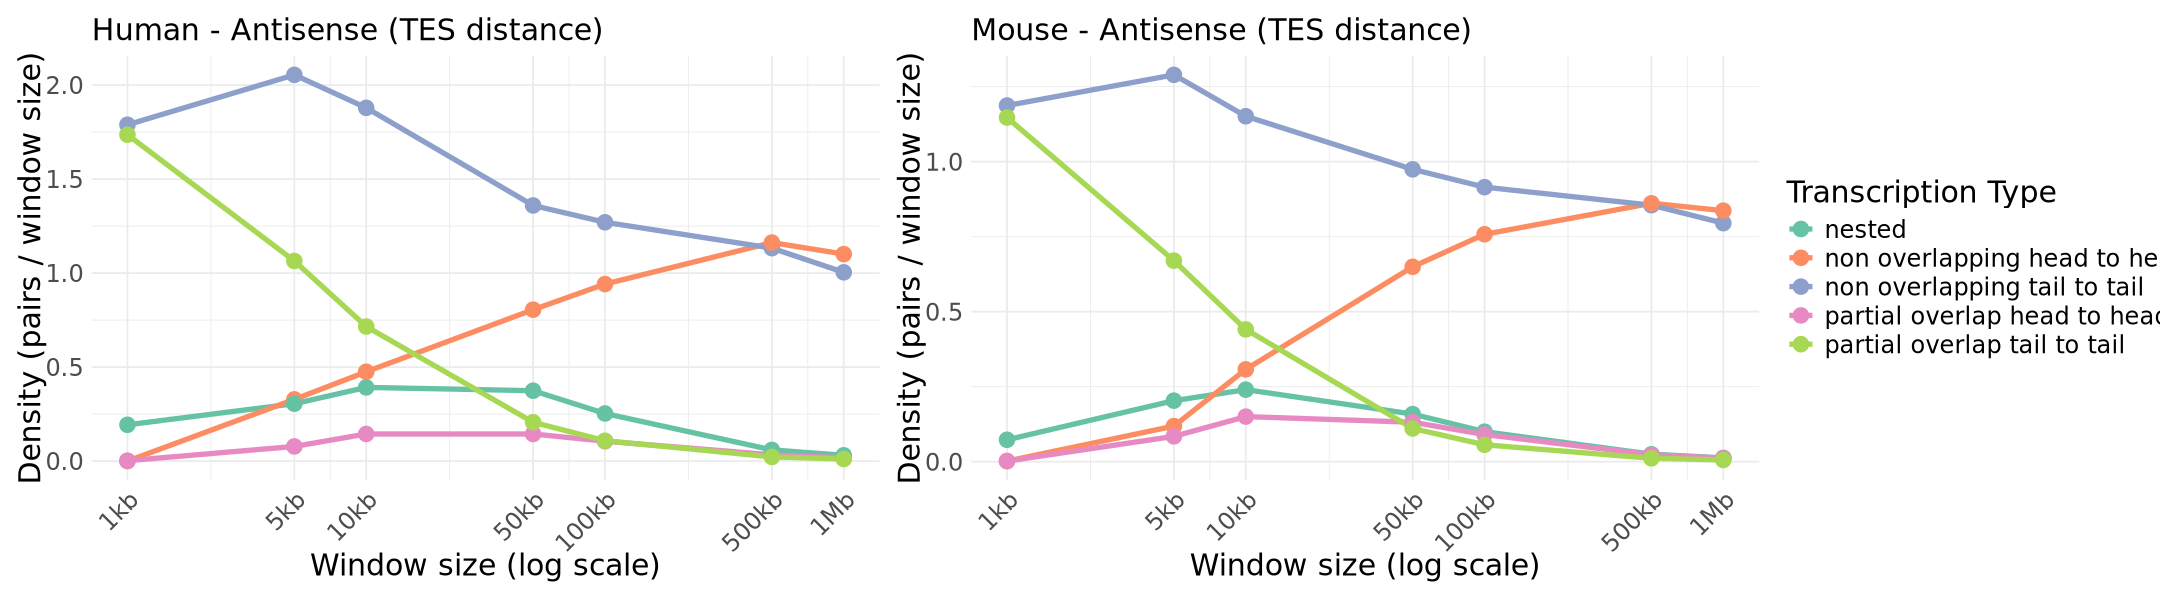

In [17]:
# Visualize antisense transcription types across window sizes
# Using TES-to-TES distance
options(repr.plot.width=16, repr.plot.height=8)

# Create separate plots for each species
p_antisense_human <- density_antisense_df %>%
    filter(species == "human") %>%
    ggplot(aes(x = window_size / 1000, y = density, 
               color = transcription_relation, group = transcription_relation)) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    scale_color_brewer(palette = "Set2") +
    theme_minimal() +
    labs(title = "Human - Antisense (TES distance)",
         x = "Window size (log scale)",
         y = "Density (pairs / window size)",
         color = "Transcription Type") +
    theme(text = element_text(size = text_size),
          plot.title = element_text(size = text_size),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "right")

p_antisense_mouse <- density_antisense_df %>%
    filter(species == "mouse") %>%
    ggplot(aes(x = window_size / 1000, y = density, 
               color = transcription_relation, group = transcription_relation)) +
    geom_line(linewidth = line_size) +
    geom_point(size = dot_size) +
    scale_x_log10(breaks = window_sizes / 1000, 
                  labels = c("1kb", "5kb", "10kb", "50kb", "100kb", "500kb", "1Mb")) +
    scale_color_brewer(palette = "Set2") +
    theme_minimal() +
    labs(title = "Mouse - Antisense (TES distance)",
         x = "Window size (log scale)",
         y = "Density (pairs / window size)",
         color = "Transcription Type") +
    theme(text = element_text(size = text_size),
          plot.title = element_text(size = text_size),
          axis.text.x = element_text(angle = 45, hjust = 1),
          legend.position = "right")

# Combine plots
p_antisense_combined <- p_antisense_human + p_antisense_mouse +
    plot_layout(guides = 'collect') & 
    theme(legend.position = 'right')

options(repr.plot.width=18, repr.plot.height=5)
p_antisense_combined

In [19]:
ggsave(filename = file.path(out_dir, paste0("Supplementary_antisense_TES_distance_", date, ".pdf")),
    plot = p_antisense_combined, 
    width = width * 1, height = 5, units = "in", dpi = dpi)